## Computing PCA and AFD methods to analyze the dataset

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import scipy
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder




In [22]:
df = pd.read_csv("data/ObesityDataSet_raw_and_data_sinthetic.csv")
n, p =df.shape

In [23]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [24]:
## Rajout de la colonne IMC_index puis mise à jour des classes de poids

df["IMC_index"] = df["Weight"]/(df["Height"]**2)

def categorize_weight(row):
    weight_index = row['Weight'] / (row['Height'] ** 2)
    if weight_index < 18.5:
        return 'Underweight'
    elif 18.5 <= weight_index < 25:
        return 'Normal'
    elif 25 <= weight_index < 30:
        return 'Overweight'
    elif 30 <= weight_index < 35:
        return 'Obesity I'
    elif 35 <= weight_index < 40:
        return 'Obesity II'
    else:
        return 'Obesity III'
    
df["Weight_class"] = df.apply(categorize_weight, axis=1)
weight_order = ["Underweight", "Normal", "Overweight", "Obesity I", "Obesity II", "Obesity III"]
df["Weight_class"] = pd.Categorical(df["Weight_class"], categories=weight_order, ordered=True)

In [25]:
numerical_variables = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE", "IMC_index"]
categorical_variables = ["Gender", "family_history_with_overweight", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS", "NObeyesdad", "Weight_class"]
labels = list(df["NObeyesdad"].unique())

In [26]:
def split_train_test(data : pd.DataFrame, test_ratio, y):
    shuffle = np.random.permutation(n)
    separator = int(test_ratio*n)
    tr_indices = shuffle[:separator]
    te_indices = shuffle[separator:]

    return data.iloc[tr_indices], data.iloc[te_indices], y[tr_indices], y[te_indices]
tr_data, te_data, y_tr, y_te = split_train_test(df, 0.8, df["Weight_class"])

In [27]:
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy='median')),
                        ("std_scaler", StandardScaler())])

full_pipeline = ColumnTransformer([("num", num_pipeline, numerical_variables),
                                   ("cat", OrdinalEncoder(), categorical_variables)], verbose_feature_names_out= False)

tr_data = full_pipeline.fit_transform(tr_data)
te_data = full_pipeline.fit_transform(te_data)

transformed_df = full_pipeline.fit_transform(df)

## Statistiques de base du dataset

In [28]:
print( " Voici la description du dataset : ")
df.describe().T

 Voici la description du dataset : 


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.000000,19.947192,22.777890,26.000000,61.000000
Height,2111.0,1.701677,0.093305,1.450000,1.630000,1.700499,1.768464,1.980000
Weight,2111.0,86.586058,26.191172,39.000000,65.473343,83.000000,107.430682,173.000000
FCVC,2111.0,2.419043,0.533927,1.000000,2.000000,2.385502,3.000000,3.000000
NCP,2111.0,2.685628,0.778039,1.000000,2.658738,3.000000,3.000000,4.000000
CH2O,2111.0,2.008011,0.612953,1.000000,1.584812,2.000000,2.477420,3.000000
FAF,2111.0,1.010298,0.850592,0.000000,0.124505,1.000000,1.666678,3.000000
TUE,2111.0,0.657866,0.608927,0.000000,0.000000,0.625350,1.000000,2.000000
IMC_index,2111.0,29.700159,8.011337,12.998685,24.325802,28.719089,36.016501,50.811753


## Correlation Heatmap

In [29]:
transformed_df = pd.DataFrame(transformed_df, columns = full_pipeline.get_feature_names_out())

In [30]:
transformed_df.corr()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,IMC_index,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad,Weight_class
Age,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931,0.244163,0.048394,0.205725,0.063902,0.083739,0.091987,-0.116283,-0.044487,-0.601945,0.236170,-0.093002
Height,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912,0.131785,0.618466,0.247684,0.178364,0.048818,0.055499,-0.133753,-0.129732,-0.073609,0.038986,0.006836
Weight,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561,0.934806,0.161668,0.496820,0.272300,0.287493,0.025746,-0.201906,-0.206677,0.004610,0.387643,-0.185588
FCVC,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135,0.263651,-0.274505,0.040372,-0.027283,-0.054670,0.014320,0.071852,-0.060781,0.064743,0.018522,0.081348
NCP,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326,0.039969,0.067600,0.071370,-0.007000,-0.097801,0.007811,-0.015624,-0.071747,-0.053858,-0.092616,0.041024
CH2O,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965,0.144200,0.107930,0.147437,0.009719,0.144995,-0.031995,0.008036,-0.091386,0.044028,0.108868,0.035009
FAF,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562,-0.177537,0.189607,-0.056673,-0.107995,-0.030110,0.011216,0.074221,0.086799,0.006394,-0.129564,0.002605
TUE,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000,-0.099720,0.017269,0.022943,0.068417,-0.048567,0.017613,-0.010928,0.045864,0.176945,-0.069448,0.049743
IMC_index,0.244163,0.131785,0.934806,0.263651,0.039969,0.144200,-0.177537,-0.099720,1.000000,-0.053035,0.483508,0.246097,0.313278,-0.000819,-0.184286,-0.169805,0.022061,0.429686,-0.204578
Gender,0.048394,0.618466,0.161668,-0.274505,0.067600,0.107930,0.189607,0.017269,-0.053035,1.000000,0.102512,0.064934,0.091543,0.044698,-0.102633,0.007616,-0.137537,0.024908,-0.098776


<Axes: >

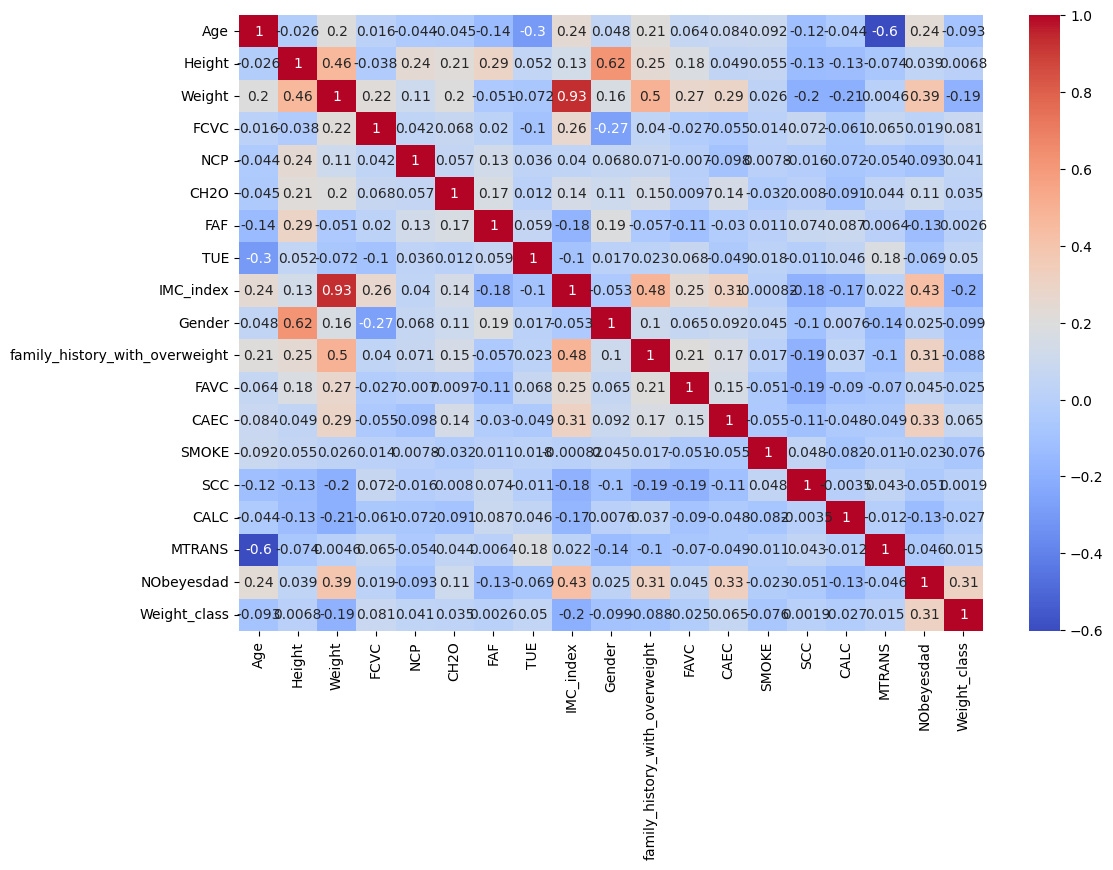

In [31]:
plt.figure(figsize=(12, 8))
sns.heatmap(transformed_df.corr(), annot = True, cmap = "coolwarm")

À la vue de ces premiers résultats, les variables les plus coréllées positivement avec IMC_index sont :
- Weight ( par définition )
- Family history with overweight
- NObeyesdad
- CAEC
- FAVC
- FCVC

Les variables corrélées négativement sont : 
- FAF
- CALC

Les variables quasi indépendantes de IMC_index sont : 
- NCP
- CH20
- TUE
- Gender
- SMOKE
- MTRANS

In [41]:
def create_displot(df, column):
    sns.displot(data = df, x = column, hue = "Weight_class", kde = True)

def create_hisplot(df, column, hue, kde = True):
    sns.histplot(data = df, x = column, hue = hue, kde = kde)

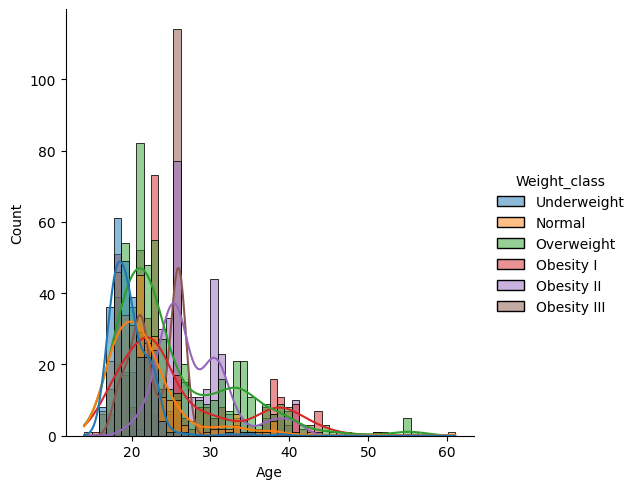

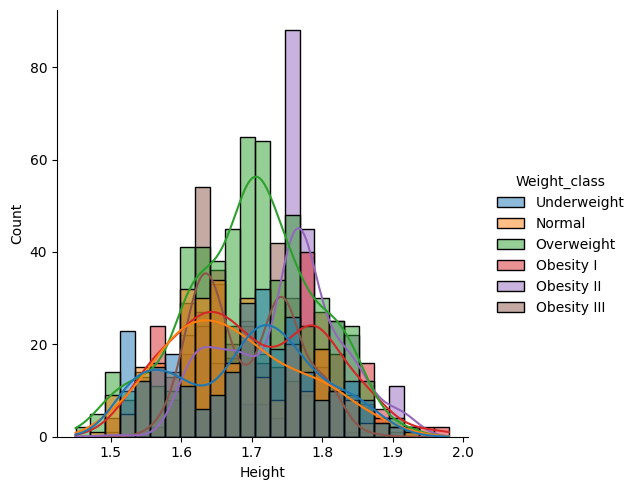

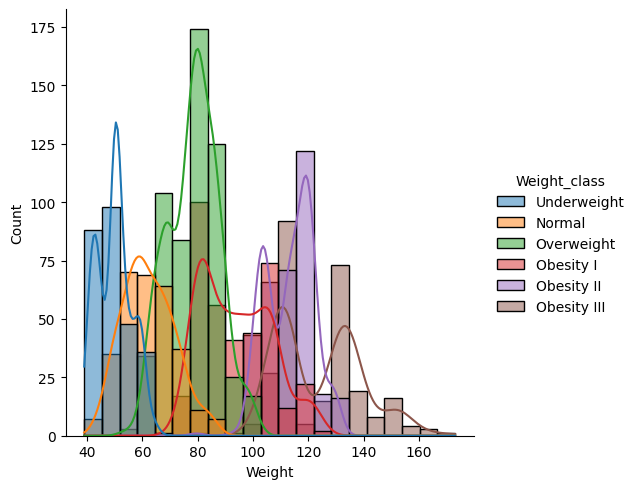

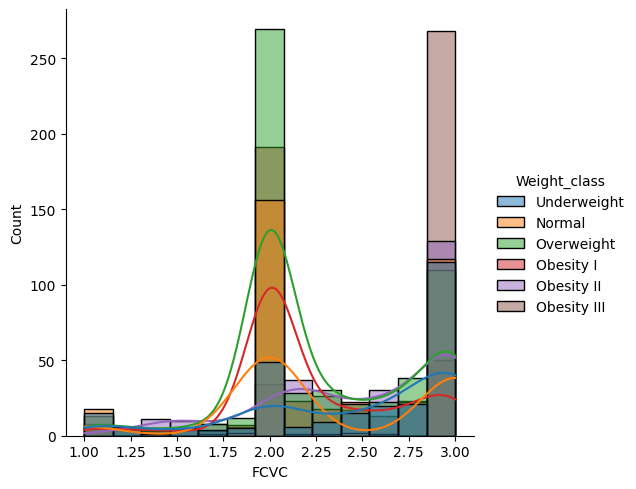

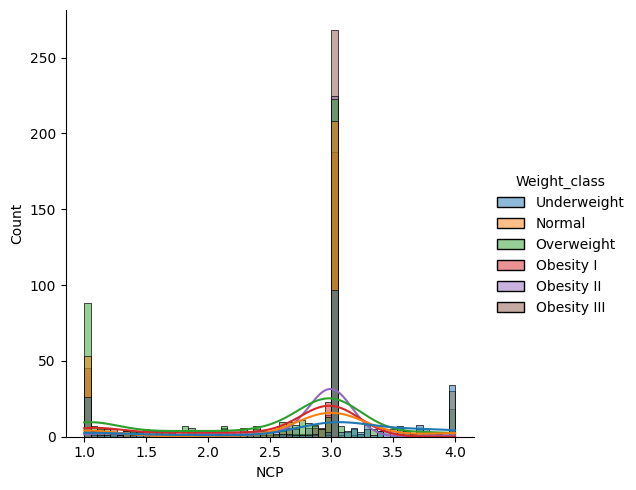

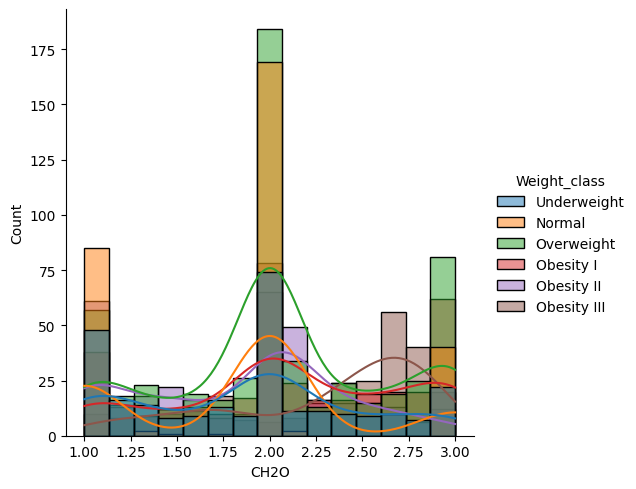

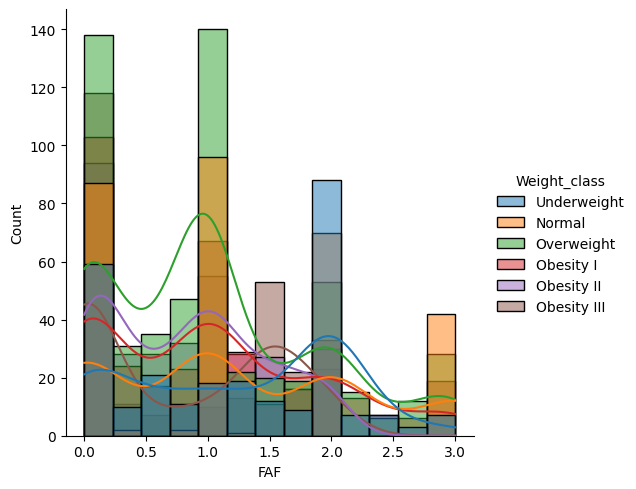

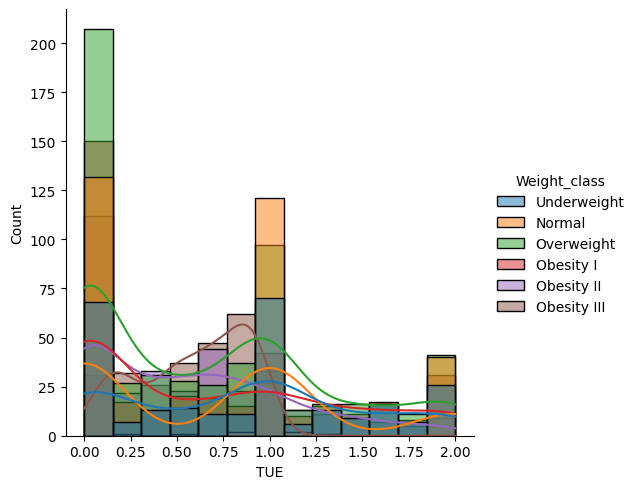

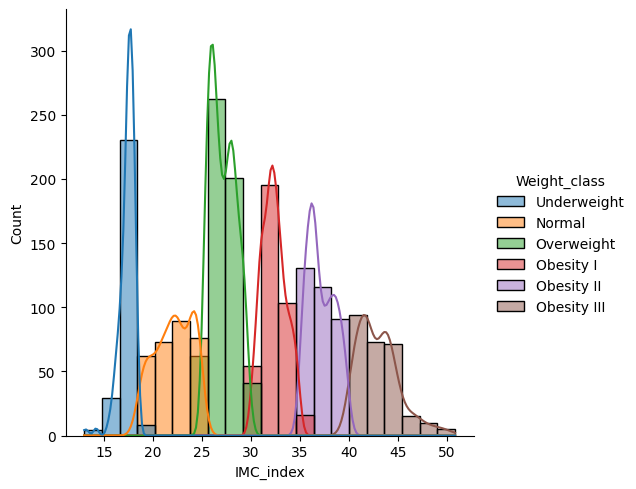

In [33]:
for i in numerical_variables:
    create_displot(df, i)

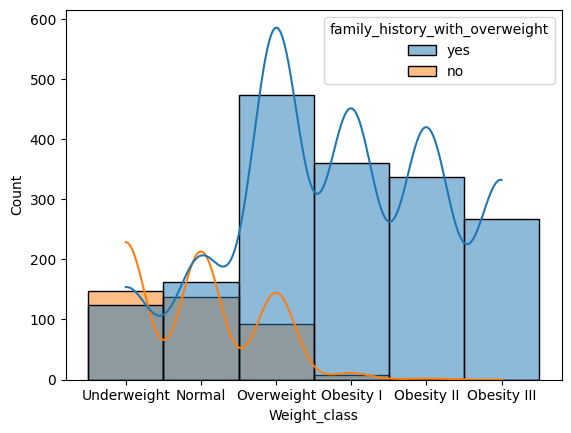

In [34]:
create_hisplot(df, column="Weight_class", hue = "family_history_with_overweight")

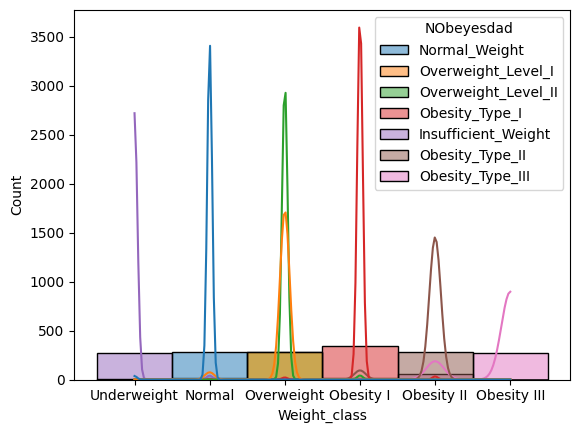

In [ ]:
create_hisplot(df, column="Weight_class", hue = "NObeyesdad")

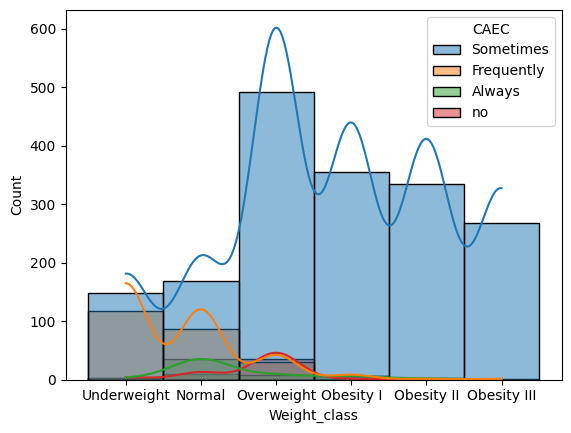

In [36]:
create_hisplot(df, column="Weight_class", hue = "CAEC")

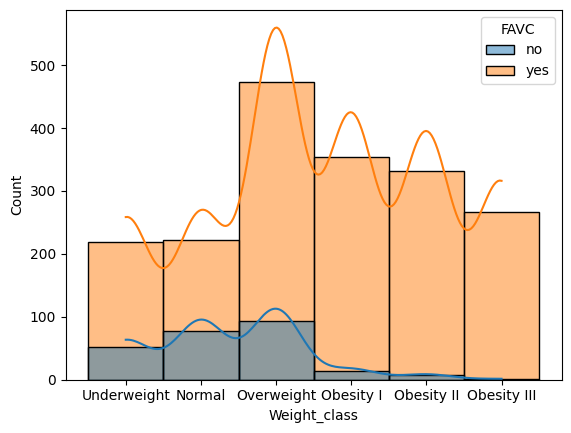

In [37]:
create_hisplot(df, column="Weight_class", hue = "FAVC")

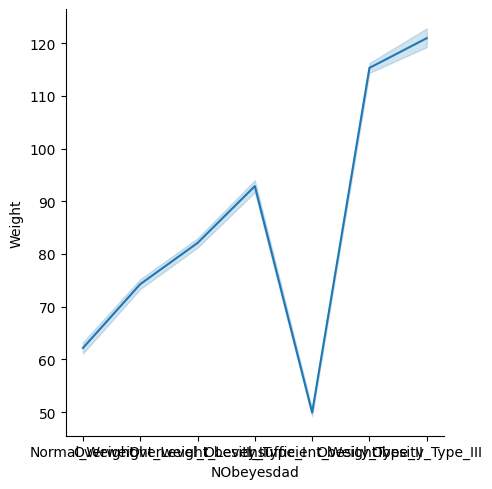

In [38]:
sns.relplot(data = df, x = "NObeyesdad", y = "Weight", kind = "line")

<Axes: xlabel='family_history_with_overweight', ylabel='IMC_index'>

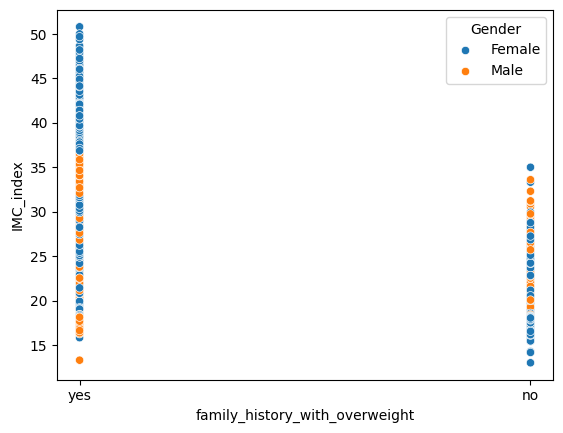

In [39]:
sns.scatterplot(data = df, x = "family_history_with_overweight", y = "IMC_index", hue = "Gender")

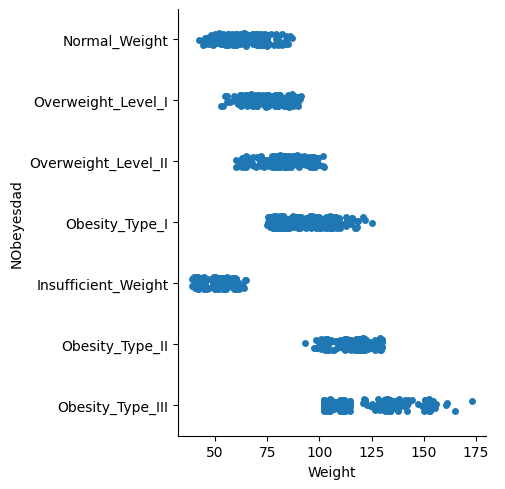

In [40]:
sns.catplot(data = df, x = "Weight", y = "NObeyesdad", kind = "strip")